In [1]:
from simulation import *
from transPCA import *

In [2]:
def run_simulation(n, p, h, rs, rp, K, fs, fp, iterate):
    """
    Run TransPCA on generated data and evaluate its performance.

    Parameters:
    - n (int): Number of samples per dataset.
    - p (int): Feature dimension.
    - h (float): Deviation factor between target and source datasets.
    - rs (int): Shared subspace dimension.
    - rp (int): Private subspace dimension per source dataset.
    - K (int): Total number of datasets (including target).
    - K_useless (int): number of useless datasets
    - fs (int): Eigenvalues for shared subspace
    - fp (int): Eigenvalues for private subspace
    """

    set_random_seed(0)
    
    # Start timing
    start_time = time.time()
    tau_range = np.logspace(-0.9, 0, 20)
    delta_range = np.logspace(-1.8, 0, 20) 
    
    # Generate data
    r = rs + rp
    K_useless = int((K-1)/2)
    Error_average = np.zeros((len(tau_range),len(delta_range))) # TransPCA with varying tau and delta under S.3 scenarios
    for i in range(len(tau_range)):
        for j in range(len(delta_range)):
            for t in range(iterate):
                tau = tau_range[i]
                delta = delta_range[j]
                target_3, source_list_3, P0_3 = generate_simulation_data_3(n, p, h, rs, rp, K, K_useless, fs, fp)
                rk_list = [r]*(len(source_list_3))
                nk_list = [n]*(len(source_list_3))
                # Run different methods under S.3 background
                # TransPCA
                model_3 = TransPCA(target_3, source_list_3, cov='covariance', r0=r, rk_list=rk_list ,delta=delta ,tau=tau , n0=n, nk_list=nk_list)
                model_3.fit()

                # Compute Frobenius norm errors
                Error_average[i,j] += (Dmetric(model_3.finetuned_U0 @ model_3.finetuned_U0.T, P0_3, r)
                                   -Dmetric(model_3.U0 @ model_3.U0.T, P0_3, r))/iterate

            del target_3, source_list_3, P0_3, model_3
            gc.collect()

    return Error_average

In [3]:
Error_average = run_simulation(n=100, p=50, h=0.1, rs=3, rp=3, K=11, fs=4, fp=8, iterate=5)

In [4]:
import pandas as pd
import seaborn as sns
from pandas.core.frame import DataFrame
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

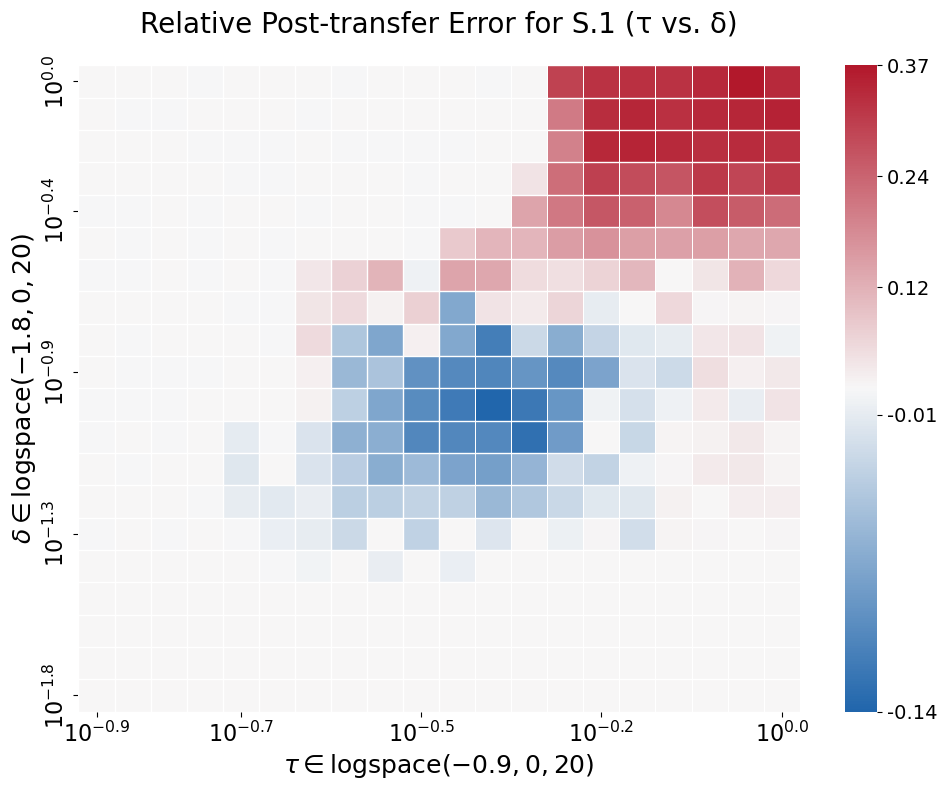

In [5]:
colors = ["#2166AC", "#F7F7F7", "#B2182B"]  # 蓝-灰-红
cmap = LinearSegmentedColormap.from_list("custom_div", colors)

# 设置颜色标准化
vmax = Error_average.max()
vmin = Error_average.min()
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# 创建对数刻度标签
tau_vals = np.logspace(-0.9, 0, 20)  # x轴（τ）
delta_vals = np.logspace(-1.8, 0, 20)  # y轴（δ）

# 创建热力图（关键修正：转置+垂直翻转）
plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(
    np.flipud(Error_average.T),  # 转置后垂直翻转，确保δ从上往下递减
    annot=False,
    cmap=cmap,
    norm=norm,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "ticks": np.linspace(vmin, vmax, 5),
        "format": "%.2f"
    }
)

# 获取colorbar对象并调整字体
cbar = heatmap.collections[0].colorbar

# 调整colorbar标签字体
cbar.ax.yaxis.label.set_size(16)  # 标题字体大小
cbar.ax.tick_params(labelsize=14)  # 刻度标签字体大小

# 设置坐标轴标签
n_ticks = 5  # 刻度数量

# X轴（τ：10^-2 → 10^0）
xticks = np.linspace(0, 19, n_ticks).astype(int)
xlabels = [r"$10^{%.1f}$" % np.log10(tau_vals[i]) for i in xticks]
plt.xticks(xticks + 0.5, xlabels, fontsize=16)

# Y轴（δ：10^-1 → 10^0，从上往下）
yticks = np.linspace(0, 19, n_ticks).astype(int)
ylabels = [r"$10^{%.1f}$" % np.log10(delta_vals[::-1][i]) for i in yticks]  # 直接使用delta_vals（已通过flipud翻转）
plt.yticks(yticks + 0.5, ylabels, fontsize=16)

# 科研级样式调整
plt.title("Relative Post-transfer Error for S.1 (τ vs. δ)", fontsize=20, pad=24)
plt.xlabel(r'$\tau \in \mathrm{logspace}(-0.9,0,20)$', fontsize=18)
plt.ylabel(r'$\delta \in \mathrm{logspace}(-1.8,0,20)$', fontsize=18)

# 添加参考线
for i in range(11):  # τ方向（10+1条竖线）
    heatmap.axvline(i, color="white", linewidth=1)
for i in range(21):  # δ方向（20+1条横线）
    heatmap.axhline(i, color="white", linewidth=1)

plt.tight_layout()
plt.show()